In [1]:
# IMPORTACIONES
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime
import plotly.express as px

In [2]:
# Resultados a partir del año...
since = 2023

# Método de llamada a la api.
def call_api(url):
    return requests.get("https://api.openf1.org/v1"+url).json()


# Obtiene la duración del stint.
def get_stint_length(lap_start, lap_end) :
    if(lap_start is None) | (lap_end is None) :
        return None
    return lap_end - lap_start + 1


# Devuelve true si en el intervalo de tiempo entre la fecha mínima y máxima ha llovido
def rain_in_interval(fecha_min, fecha_max, current_tyre, weather):
    fecha_min = datetime.fromisoformat(fecha_min)
    fecha_max = datetime.fromisoformat(fecha_max)

    datos_intervalos = [data for data in weather if (fecha_min <= datetime.fromisoformat(data["date"]) <= fecha_max)]
    return any(data["rainfall"] == 1 for data in datos_intervalos) if len(datos_intervalos) > 0 else current_tyre == "WET" or current_tyre == "INTERMEDIATE"


# Devuelve true si durante esas vueltas ha llovido
def check_rain(laps_list, current_tyre, weather):
    if len(laps_list) == 0:
        return current_tyre == "WET" or current_tyre == "INTERMEDIATE"
    fecha_min = min(lap['date_start'] for lap in laps_list)
    fecha_max = max(lap['date_start'] for lap in laps_list)
    return rain_in_interval(fecha_min, fecha_max, current_tyre, weather)

# Devuelve true si durante el stint hubo periodo de Safety Car o Virtual Safety Car
def check_vc_vsc(row, df_sc):
    subset = df_sc[(df_sc['circuit'] == row['circuit']) & (df_sc['race_year'] == row['race_year'])]
    intersect = subset[(subset['start_lap'] <= row['lap_end']) & (subset['end_lap'] >= row['lap_start'])]
    
    vsc = 'VSC' in intersect['type'].values
    sc = 'SC' in intersect['type'].values
    
    return pd.Series({'SC': sc, 'VSC': vsc})


# Convierte el csv en dataframe y observamos el número de nulos por columna.
def get_df(csv):
    return pd.DataFrame(csv)


# Devuelve el numero de nulos por columna.
def get_null_columns(df):
    print(df.isnull().sum())


# Convierte un dataframe en un archivo csv.
def dataframe_to_CSV(df, name, header, index):
    df.to_csv(name,header=header,index=index)

In [3]:
# Crea un CSV con los datos del piloto, carrera y stints.
circuits = call_api("/sessions?session_name=Race&year>="+str(since))

if 'detail' in circuits:
    print("Evento en curso, la obtencion de datos no funcionará hasta que finalice.")
else:
    data_to_csv = []

    for circuit in circuits:
        drivers =  call_api("/drivers?session_key="+str(circuit['session_key']))
        stints = call_api("/stints?session_key="+str(circuit['session_key']))
        laps = call_api("/laps?session_key="+str(circuit['session_key']))
        weather = call_api("/weather?session_key="+str(circuit['session_key']))
         
        for driver in drivers:
            stints_driver = [stint for stint in stints if stint['driver_number'] == driver['driver_number']]
            for stint in stints_driver:
                row = {}
                row['race_id'] = circuit['session_key']
                row['driver_id'] = driver['driver_number']
                row['circuit'] = circuit['circuit_short_name']
                row['race_year'] = circuit['year']
                row['stint_number'] = stint['stint_number']
                row['lap_start'] = stint['lap_start'] if stint['lap_start'] else 0
                row['lap_end'] = stint['lap_end'] if stint['lap_end'] else 0
                row['current_tyre'] = stint['compound']
                laps_driver = [lap for lap in laps if lap['driver_number'] == driver['driver_number']]
                laps_list = [lap for lap in laps_driver if lap['lap_number']>=row['lap_start'] and lap['lap_number']<=row['lap_end'] and lap['date_start']  is not None]
                row['rain'] = check_rain(laps_list,  row['current_tyre'] , weather)
                data_to_csv.append(row)


# Exploración Inicial df_1

In [4]:
# Descripción DataFrame df_1.
df_1 = get_df(data_to_csv)
df_1

,race_id,driver_id,circuit,race_year,stint_number,lap_start,lap_end,current_tyre,rain
0,7953,1,Sakhir,2023,1,1,14,SOFT,False
1,7953,1,Sakhir,2023,2,15,36,SOFT,False
2,7953,1,Sakhir,2023,3,37,57,HARD,False
3,7953,2,Sakhir,2023,1,1,12,SOFT,False
4,7953,2,Sakhir,2023,2,13,30,SOFT,False
...,...,...,...,...,...,...,...,...,...
3972,9839,63,Yas Marina Circuit,2025,2,15,58,HARD,False
3973,9839,81,Yas Marina Circuit,2025,1,1,41,HARD,False
3974,9839,81,Yas Marina Circuit,2025,2,42,58,MEDIUM,False
3975,9839,87,Yas Marina Circuit,2025,1,1,14,MEDIUM,False


In [5]:
print('Shape: ', df_1.shape) 
print('Size: ', df_1.size) 
print(len(df_1)*len(df_1.columns))

Shape:  (3977, 9)
Size:  35793
35793


In [6]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3977 entries, 0 to 3976
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   race_id       3977 non-null   int64 
 1   driver_id     3977 non-null   int64 
 2   circuit       3977 non-null   object
 3   race_year     3977 non-null   int64 
 4   stint_number  3977 non-null   int64 
 5   lap_start     3977 non-null   int64 
 6   lap_end       3977 non-null   int64 
 7   current_tyre  3977 non-null   object
 8   rain          3977 non-null   bool  
dtypes: bool(1), int64(6), object(2)
memory usage: 252.6+ KB


In [7]:
get_null_columns(df_1)

race_id         0
driver_id       0
circuit         0
race_year       0
stint_number    0
lap_start       0
lap_end         0
current_tyre    0
rain            0
dtype: int64


In [8]:
duplicados = df_1.duplicated(subset=["race_id", "driver_id", "stint_number"])
print("Número de duplicados:", duplicados.sum())

Número de duplicados: 0


### Análisis inicial de variables numéricas df_1

In [9]:
# Análisis inicial de variables numéricas.
num_cols = df_1.select_dtypes(include=np.number).columns.tolist()
print(df_1[num_cols].describe())

df_1_long = df_1[num_cols].melt(var_name="variable", value_name="value")

fig = px.box(
    df_1_long,
    x="variable",
    y="value",
    points="outliers",                
)

fig.update_layout(
    font=dict(family='Work sans', size=18, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    xaxis_title="Variable",
    yaxis_title="Valor",
    showlegend=True,
    height=800
)
fig.update_traces(marker_color='#7C93C3')
fig.show()

            race_id    driver_id    race_year  stint_number    lap_start  \
count   3977.000000  3977.000000  3977.000000   3977.000000  3977.000000   
mean    9478.312296    28.646719  2023.991954      2.135026    18.444305   
std      485.907380    23.828596     0.819122      1.160259    18.762963   
min     7779.000000     1.000000  2023.000000      1.000000     0.000000   
25%     9181.000000    11.000000  2023.000000      1.000000     1.000000   
50%     9566.000000    22.000000  2024.000000      2.000000    13.000000   
75%     9877.000000    44.000000  2025.000000      3.000000    33.000000   
max    10033.000000    87.000000  2025.000000      8.000000    77.000000   

           lap_end  
count  3977.000000  
mean     37.048780  
std      21.489718  
min       0.000000  
25%      18.000000  
50%      37.000000  
75%      56.000000  
max      78.000000  


In [10]:

(  df_1.select_dtypes(np.number).dtypes.to_frame("Tipo")
  .assign(Cardinalidad = df_1.nunique())
  .assign(Granularidad = df_1.nunique() / len(df_1) * 100)
  .assign(Nulos_Pct = (df_1.isnull().sum() / len(df_1) * 100).round(2))
  .assign(Max = df_1.dropna().apply(max))
  .assign(Min = df_1.dropna().apply(min))
  .sort_values("Tipo")
)

,Tipo,Cardinalidad,Granularidad,Nulos_Pct,Max,Min
race_id,int64,70,1.760121,0.0,10033,7779
driver_id,int64,32,0.804627,0.0,87,1
race_year,int64,3,0.075434,0.0,2025,2023
stint_number,int64,8,0.201157,0.0,8,1
lap_start,int64,73,1.835554,0.0,77,0
lap_end,int64,77,1.936133,0.0,78,0


In [11]:
# Análisis de la variable race_id.
num_cols = ["race_id"]

# Visualización de la distribución de la variable race_id.
df_1_long = df_1[num_cols].melt(var_name="variable", value_name="value")

fig = px.box(
    df_1_long,
    x="variable",
    y="value",
    points="outliers"
)

fig.update_layout(
    font=dict(family='Work sans', size=18, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    xaxis_title="Variable",
    yaxis_title="Valor",
    showlegend=True,
    height=600
)

fig.update_traces(marker_color='#7C93C3')
fig.show()


In [12]:
df_1[df_1["race_id"].isin([7953, 7787, 7779])][["race_id", "race_year", "circuit"]]


,race_id,race_year,circuit
0,7953,2023,Sakhir
1,7953,2023,Sakhir
2,7953,2023,Sakhir
3,7953,2023,Sakhir
4,7953,2023,Sakhir
...,...,...,...
194,7787,2023,Melbourne
195,7787,2023,Melbourne
196,7787,2023,Melbourne
197,7787,2023,Melbourne


In [13]:
df_1[df_1["race_id"].isin([7953, 7787, 7779])].groupby("race_id").size()


race_id
7779    44
7787    85
7953    70
dtype: int64

In [14]:
df_1.sort_values("race_year")[["race_id", "race_year"]].drop_duplicates().head(15)


,race_id,race_year
0,7953,2023
70,7779,2023
114,7787,2023
199,9070,2023
242,9078,2023
282,9094,2023
339,9102,2023
402,9110,2023
455,9118,2023
538,9126,2023


In [15]:
# Boxplots de las variables stint_number, lap_start y lap_end.
num_cols = ["stint_number", "lap_start", "lap_end"]

df_1_long = df_1[num_cols].melt(var_name="variable", value_name="value")

fig = px.box(
    df_1_long,
    x="variable",
    y="value",
    points="outliers"
)

fig.update_layout(
    font=dict(family='Work sans', size=18, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    xaxis_title="Variable",
    yaxis_title="Valor",
    showlegend=True,
    height=600
)

fig.update_traces(marker_color='#7C93C3')
fig.show()


In [16]:
# Histogramas de las variables stint_number, lap_start y lap_end.
exclude = {'race_id', 'driver_id', 'race_year'}

cols_to_plot = [
    c for c in df_1.select_dtypes(np.number).columns
    if c not in exclude
]
for c in cols_to_plot:
    fig = px.histogram(
        df_1,
        x=c,
        nbins=30,           
        histnorm='percent'  
    )
    
    fig.update_layout(
        font=dict(family='Work sans', size=18, color='#425563'),
        plot_bgcolor='#F2F3F2',
        paper_bgcolor='white',
        xaxis_title=c,
        yaxis_title="Frecuencia", 
        showlegend=False,
        height=500,
        width=1000
    )
    
    fig.update_traces(marker_color='#7C93C3')
    fig.show()

### Análisis inicial de variables categóricas df_1

In [17]:
df_1.describe(include='object')

,circuit,current_tyre
count,3977,3977
unique,24,6
top,Melbourne,MEDIUM
freq,246,1526


In [18]:
categorical_columns_toexplore = ['circuit', 'race_year', 'current_tyre', 'rain']

for column in categorical_columns_toexplore:
    print(column, ":", df_1[column].unique(), "\n")

circuit : ['Sakhir' 'Jeddah' 'Melbourne' 'Baku' 'Miami' 'Monte Carlo' 'Catalunya'
 'Montreal' 'Spielberg' 'Silverstone' 'Hungaroring' 'Spa-Francorchamps'
 'Zandvoort' 'Monza' 'Singapore' 'Suzuka' 'Lusail' 'Austin' 'Mexico City'
 'Interlagos' 'Las Vegas' 'Yas Marina Circuit' 'Shanghai' 'Imola'] 

race_year : [2023 2024 2025] 

current_tyre : ['SOFT' 'HARD' 'MEDIUM' 'INTERMEDIATE' 'WET' 'UNKNOWN'] 

rain : [False  True] 



In [19]:
# Gráfico de barras de las variables current_tyre y rain.
cat_low = ['current_tyre', 'rain']

for col in cat_low:
    if col == 'race_year':
        df_plot = df_1[df_1[col].isin([2023, 2024, 2025])]
    else:
        df_plot = df_1.copy()
    
    df_plot = df_plot[col].value_counts(normalize=True).reset_index()
    df_plot.columns = [col, 'proportion']
    
    fig = px.bar(
        df_plot,
        x=col,
        y='proportion',
        labels={col: col, 'proportion': 'Proporción'}
    )
    
    fig.update_traces(marker_color='#7C93C3', text=None)  # Sin texto en barras
    fig.update_layout(
        font=dict(family='Work sans', size=16, color='#425563'),
        plot_bgcolor='#F2F3F2',
        paper_bgcolor='white',
        height=400,
        width=700,
        yaxis_tickformat='0%',  # Eje y sin decimales
        yaxis=dict(tickformat='0%')
    )
    
    fig.show()


In [20]:
# Gráfico de barras horizontales num_stints y circuit.
circuit_counts = df_1['circuit'].value_counts().reset_index()
circuit_counts.columns = ['circuit', 'num_stints']

fig = px.bar(
    circuit_counts.sort_values('num_stints'),
    x='num_stints',
    y='circuit',
    orientation='h',
    text='num_stints'
)
fig.update_traces(marker_color='#7C93C3', text=None)
fig.update_layout(
    font=dict(family='Work sans', size=16, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    height=600,
    width=800
)
fig.show()


## Transformaciones y ajustes de variables df_1
### Gestión de nulos y campos vacíos

In [21]:
# Cálculo del número y procentage de nulos por columna.
num_nulls = df_1.isnull().sum()

percent_nulls = (num_nulls / len(df_1)) * 100

null_summary_df = pd.DataFrame({
    'Number of Nulls': num_nulls,
    'Percentage': percent_nulls
})

null_summary_df['Percentage'] = null_summary_df['Percentage'].round(2)

print(null_summary_df)

              Number of Nulls  Percentage
race_id                     0         0.0
driver_id                   0         0.0
circuit                     0         0.0
race_year                   0         0.0
stint_number                0         0.0
lap_start                   0         0.0
lap_end                     0         0.0
current_tyre                0         0.0
rain                        0         0.0


In [22]:
# Visualización de los valores nulos por registro. 1 = nulo, 0 = no nulo
m = df_1.isna().astype(int)  
fig = px.imshow(
    m.T,  
    
    aspect='auto',
    labels=dict(color="Nulo (1)"),
    title="Mapa de nulos por columna/registro"
)
fig.update_yaxes(title="Columna", tickvals=list(range(len(df_1.columns))), ticktext=df_1.columns)
fig.update_xaxes(title="Fila (índice)")
fig.show()

### Gestión de duplicados

In [23]:
# Detección de duplicados
print('Número de duplicados: ', df_1.duplicated().sum())
df_1[df_1.duplicated()].head()

Número de duplicados:  0


,race_id,driver_id,circuit,race_year,stint_number,lap_start,lap_end,current_tyre,rain


## Feature Engineering df

In [24]:
df = get_df(data_to_csv)
# Se rellenan los campos lap_start y lap_end con 0 en caso de ser nulos, eso significa que no han acabado la primera vuelta
df['lap_start'] = df['lap_start'].fillna(0).astype(int)
df['lap_end'] = df['lap_end'].fillna(0).astype(int)
# Se calcula la longitud de los stints
df['stint_length']  = get_stint_length(df['lap_start'], df['lap_end'])
# Si el neumatico es indeterminado se elige una opción intermedia como sería normalmente el neumatico medio
df["current_tyre"] = df["current_tyre"].replace("UNKNOWN", "MEDIUM")
get_null_columns(df)
df

race_id         0
driver_id       0
circuit         0
race_year       0
stint_number    0
lap_start       0
lap_end         0
current_tyre    0
rain            0
stint_length    0
dtype: int64


,race_id,driver_id,circuit,race_year,stint_number,lap_start,lap_end,current_tyre,rain,stint_length
0,7953,1,Sakhir,2023,1,1,14,SOFT,False,14
1,7953,1,Sakhir,2023,2,15,36,SOFT,False,22
2,7953,1,Sakhir,2023,3,37,57,HARD,False,21
3,7953,2,Sakhir,2023,1,1,12,SOFT,False,12
4,7953,2,Sakhir,2023,2,13,30,SOFT,False,18
...,...,...,...,...,...,...,...,...,...,...
3972,9839,63,Yas Marina Circuit,2025,2,15,58,HARD,False,44
3973,9839,81,Yas Marina Circuit,2025,1,1,41,HARD,False,41
3974,9839,81,Yas Marina Circuit,2025,2,42,58,MEDIUM,False,17
3975,9839,87,Yas Marina Circuit,2025,1,1,14,MEDIUM,False,14


In [25]:
# Visualización de la frecuencia de stint_length.
fig = px.histogram(
    df,
    x='stint_length',
    nbins=40,
)

fig.update_layout(
    font=dict(family='Work sans', size=16, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    xaxis_title='stint_length',
    yaxis_title='Frecuencia'
)

fig.update_traces(marker_color='#7C93C3')
fig.show()


In [26]:
# Se calculan las vueltas totales por carrera para posteriormente utilizarlo en el calculo de vueltas restantes
df_total_laps = df.groupby(['circuit', 'race_year'])["lap_end"].max().astype(int).reset_index()
df_total_laps = df_total_laps.rename(columns={'lap_end': 'total_laps'})
df = pd.merge(left=df, right=df_total_laps, how='left', on=['circuit', 'race_year'])
df['laps_remaining'] = df['total_laps'] - df['lap_end']
df

,race_id,driver_id,circuit,race_year,stint_number,lap_start,lap_end,current_tyre,rain,stint_length,total_laps,laps_remaining
0,7953,1,Sakhir,2023,1,1,14,SOFT,False,14,57,43
1,7953,1,Sakhir,2023,2,15,36,SOFT,False,22,57,21
2,7953,1,Sakhir,2023,3,37,57,HARD,False,21,57,0
3,7953,2,Sakhir,2023,1,1,12,SOFT,False,12,57,45
4,7953,2,Sakhir,2023,2,13,30,SOFT,False,18,57,27
...,...,...,...,...,...,...,...,...,...,...,...,...
3972,9839,63,Yas Marina Circuit,2025,2,15,58,HARD,False,44,58,0
3973,9839,81,Yas Marina Circuit,2025,1,1,41,HARD,False,41,58,17
3974,9839,81,Yas Marina Circuit,2025,2,42,58,MEDIUM,False,17,58,0
3975,9839,87,Yas Marina Circuit,2025,1,1,14,MEDIUM,False,14,58,44


In [27]:
color_map = {
    "INTERMEDIATE": "green",
    "SOFT": "red",
    "MEDIUM": "yellow",
    "HARD": "white",
    "WET": "blue"
}

fig_box = px.box(
    df,
    x="current_tyre",
    y="stint_length",
    points="outliers",
    color="current_tyre",
    color_discrete_map=color_map,
    category_orders={
        "current_tyre": ["HARD", "MEDIUM", "SOFT", "INTERMEDIATE", "WET"]
    },
    labels={
        "current_tyre": "current_tyre",
        "stint_length": "stint_length"
    }
)

for trace in fig_box.data:
    current_tyre = trace.name.upper()
    trace.line.color = "black"
    trace.line.width = 2
    trace.fillcolor = color_map[current_tyre] 

fig_box.update_layout(
    font=dict(family='Work sans', size=18, color='#425563'),
    plot_bgcolor='#D6D6D6',
    paper_bgcolor='white',
    showlegend=False,
    height=600
)

fig_box.show()

In [28]:
# Visualización vueltas restantes por stint.
fig = px.box(
    df,
    x="stint_number",
    y="laps_remaining",
    points="outliers",
)

fig.update_layout(
    font=dict(family='Work sans', size=18, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    xaxis_title="stint_number",
    yaxis_title="laps_remaining",
    showlegend=True,
    height=600
)

fig.update_traces(marker_color='#7C93C3')
fig.show()

In [29]:
df = df.sort_values(['driver_id', 'race_year','circuit', 'stint_number'])

# Se agrupa por piloto, circuito y año el neumático usado en cada stint para crear un listado de neúmaticos usados hasta el momento
df['tyres_used_so_far'] = (
    df.groupby(['driver_id', 'circuit', 'race_year'])['current_tyre']
      .transform(lambda x: [list(x.iloc[:i+1]) for i in range(len(x))])
)

# Se calcula el número de paradas realizadas en la carrera y consideramos como valores anómalos (outliers) los registros de pilotos que han realizado más de 3 paradas
df_pits_in_race = df.groupby(['driver_id', 'circuit', 'race_year'])["stint_number"].max().astype(int).reset_index()
df_pits_in_race = df_pits_in_race[df_pits_in_race['stint_number'] <= 4]

df_pits_in_race = df_pits_in_race.rename(columns={'stint_number': 'pits_total'})
df = pd.merge(left=df, right=df_pits_in_race, how='inner', on=['driver_id', 'circuit', 'race_year'])

get_null_columns(df)
df.head(6)

race_id              0
driver_id            0
circuit              0
race_year            0
stint_number         0
lap_start            0
lap_end              0
current_tyre         0
rain                 0
stint_length         0
total_laps           0
laps_remaining       0
tyres_used_so_far    0
pits_total           0
dtype: int64


,race_id,driver_id,circuit,race_year,stint_number,lap_start,lap_end,current_tyre,rain,stint_length,total_laps,laps_remaining,tyres_used_so_far,pits_total
0,9213,1,Austin,2023,1,1,16,MEDIUM,False,16,56,40,[MEDIUM],3
1,9213,1,Austin,2023,2,17,35,MEDIUM,False,19,56,21,"[MEDIUM, MEDIUM]",3
2,9213,1,Austin,2023,3,36,56,HARD,False,21,56,0,"[MEDIUM, MEDIUM, HARD]",3
3,9070,1,Baku,2023,1,1,10,MEDIUM,False,10,51,41,[MEDIUM],2
4,9070,1,Baku,2023,2,11,51,HARD,False,41,51,0,"[MEDIUM, HARD]",2
5,9102,1,Catalunya,2023,1,1,26,MEDIUM,False,26,66,40,[MEDIUM],3


In [30]:
# Diagrama de barras de número de pits_total.
df_counts = df['pits_total'].value_counts().sort_index().reset_index()

fig = px.bar(
    df_counts,
    x='pits_total',  
    y='count',       
    labels={'pits_total': 'pits_total', 'count': 'count'},
)

fig.update_layout(
    font=dict(family='Work sans', size=16, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white'
)

fig.update_xaxes(
    tickvals=[2, 3, 4]
)

fig.update_traces(marker_color='#7C93C3')
fig.show()

In [31]:
# Crea un CSV con los datos de la carrera e información sobre los SC y VSC.
circuits_race_sc = call_api("/sessions?session_name=Race&year>="+str(since))

if 'detail' in circuits_race_sc:
    print("Evento en curso, la obtencion de datos no funcionará hasta que finalice.")
else:
    data_sc_csv = []

    for circuit in circuits_race_sc:
        race_control = call_api("/race_control?session_key="+str(circuit['session_key'])+"&category=SafetyCar")
        race_control_vsc_start = [item for item in race_control if item["message"] == "VIRTUAL SAFETY CAR DEPLOYED"]
        race_control_vsc_end = [item for item in race_control if item["message"] == "VIRTUAL SAFETY CAR ENDING"]
        race_control_sc_start = [item for item in race_control if item["message"] == "SAFETY CAR DEPLOYED"]
        race_control_sc_end = [item for item in race_control if item["message"] == "SAFETY CAR IN THIS LAP"]

        for index in range(len(race_control_sc_start)):
            row = {}
            row['circuit'] = circuit['circuit_short_name']
            row['race_year'] = circuit['year']
            row['start_lap'] = race_control_sc_start[index]['lap_number']
            row['end_lap'] = race_control_sc_end[index]['lap_number'] if index < len(race_control_sc_end) else None
            row['type'] = "SC"
            data_sc_csv.append(row)

        for index in range(len(race_control_vsc_start)):
            row = {}
            row['circuit'] = circuit['circuit_short_name']
            row['race_year'] = circuit['year']
            row['start_lap'] = race_control_vsc_start[index]['lap_number']
            row['end_lap'] = race_control_vsc_end[index]['lap_number'] if index < len(race_control_vsc_end) else None
            row['type'] = "VSC"
            data_sc_csv.append(row)

# Exploración Inicial df_sc_1

In [32]:
df_sc_1 = get_df(data_sc_csv)
df_sc_1

,circuit,race_year,start_lap,end_lap,type
0,Sakhir,2023,41,42.0,VSC
1,Jeddah,2023,18,20.0,SC
2,Melbourne,2023,1,3.0,SC
3,Melbourne,2023,7,NaN,SC
4,Melbourne,2023,54,NaN,SC
...,...,...,...,...,...
73,Interlagos,2025,2,5.0,SC
74,Interlagos,2025,7,8.0,VSC
75,Las Vegas,2025,2,4.0,VSC
76,Las Vegas,2025,16,16.0,VSC


In [33]:
print('Shape: ', df_sc_1.shape) 
print('Size: ', df_sc_1.size) 
print(len(df)*len(df_sc_1.columns))

Shape:  (78, 5)
Size:  390
16980


In [34]:
df_sc_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   circuit    78 non-null     object 
 1   race_year  78 non-null     int64  
 2   start_lap  78 non-null     int64  
 3   end_lap    66 non-null     float64
 4   type       78 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 3.2+ KB


In [35]:
get_null_columns(df_sc_1)

circuit       0
race_year     0
start_lap     0
end_lap      12
type          0
dtype: int64


In [36]:
duplicados = df_sc_1.duplicated()
print("Número de duplicados:", duplicados.sum())

Número de duplicados: 0


### Análisis inicial de variables numéricas df_sc_1

In [37]:
# Visualización mediante diagrama de cajas de las variables númericas.
num_cols = ["start_lap", "end_lap"]
print(df_sc_1[num_cols].describe())

df_sc_1_long = df_sc_1[num_cols].melt(var_name="variable", value_name="value")

fig = px.box(
    df_sc_1_long,
    x="variable",
    y="value",
    points="outliers",
)

fig.update_layout(
    font=dict(family='Work sans', size=18, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    xaxis_title="Variable",
    yaxis_title="Valor",
    showlegend=True,
    height=600
)

fig.update_traces(marker_color='#7C93C3')
fig.show()

       start_lap    end_lap
count  78.000000  66.000000
mean   23.102564  22.772727
std    20.110467  19.047144
min     1.000000   2.000000
25%     3.500000   5.250000
50%    19.000000  18.500000
75%    33.750000  33.500000
max    70.000000  71.000000


In [38]:

(  df_sc_1.select_dtypes(np.number).dtypes.to_frame("Tipo")
  .assign(Cardinalidad = df_sc_1.nunique())
  .assign(Granularidad = df_sc_1.nunique() / len(df_sc_1) * 100)
  .assign(Nulos_Pct = (df_sc_1.isnull().sum() / len(df_sc_1) * 100).round(2))
  .assign(Max = df_sc_1.dropna().apply(max))
  .assign(Min = df_sc_1.dropna().apply(min))
  .sort_values("Tipo")
)

,Tipo,Cardinalidad,Granularidad,Nulos_Pct,Max,Min
race_year,int64,3,3.846154,0.00,2025,2023
start_lap,int64,42,53.846154,0.00,70,1
end_lap,float64,40,51.282051,15.38,71.0,2.0


### Análisis inicial de variables categóricas df_sc_1

In [39]:
df_sc_1.describe(include='object')

,circuit,type
count,78,78
unique,21,2
top,Melbourne,SC
freq,9,46


In [40]:
categorical_columns_toexplore = ['circuit', 'type']

for column in categorical_columns_toexplore:
    print(column, ":", df_sc_1[column].unique(), "\n")

circuit : ['Sakhir' 'Jeddah' 'Melbourne' 'Baku' 'Montreal' 'Spielberg' 'Silverstone'
 'Zandvoort' 'Singapore' 'Suzuka' 'Lusail' 'Mexico City' 'Interlagos'
 'Las Vegas' 'Shanghai' 'Miami' 'Austin' 'Yas Marina Circuit' 'Imola'
 'Monte Carlo' 'Catalunya'] 

type : ['VSC' 'SC'] 



In [41]:
# Gráfico barras horizontales eventos SC y VSC por circuito.
sc_counts = (
    df_sc_1.groupby(['circuit', 'type'])
         .size()
         .reset_index(name='num_events')
)

order_circuits = (
    sc_counts.groupby('circuit')['num_events']
             .sum()
             .sort_values(ascending=False)
             .index
)
fig = px.bar(
    sc_counts,
    x='num_events',
    y='circuit',
    color='type',
    orientation='h',
    category_orders={'circuit': list(order_circuits)},
    color_discrete_map={
        'SC': '#E63946',     
        'VSC': '#F4A261'     
    },
    labels={
        'num_events': 'type',
        'circuit': 'circuit',
        'type': 'Tipo de neutralización'
    }
)
fig.update_layout(
    font=dict(family='Work sans', size=16, color='#425563'),
    plot_bgcolor='#F2F3F2',
    paper_bgcolor='white',
    height=650,
    width=900,
    barmode='stack'
)

fig.show()


## Transformaciones y ajustes de variables df_sc_1
### Gestión de nulos y campos vacíos

In [42]:
# Cálculo de valores y porcentage de valores nulos por columna.
num_nulls = df_sc_1.isnull().sum()

percent_nulls = (num_nulls / len(df_sc_1)) * 100

null_summary_df = pd.DataFrame({
    'Number of Nulls': num_nulls,
    'Percentage': percent_nulls
})

null_summary_df['Percentage'] = null_summary_df['Percentage'].round(2)

print(null_summary_df)

           Number of Nulls  Percentage
circuit                  0        0.00
race_year                0        0.00
start_lap                0        0.00
end_lap                 12       15.38
type                     0        0.00


In [43]:
# Visualización del número de nulos por registro. 1 = nulo, 0 = no nulo.
m = df_sc_1.isna().astype(int)  
fig = px.imshow(
    m.T,  
    aspect='auto',
    labels=dict(color="Nulo (1)"),
)
fig.update_yaxes(title="Columna", tickvals=list(range(len(df_sc_1.columns))), ticktext=df_sc_1.columns)
fig.update_xaxes(title="Fila (índice)")
fig.show()

In [44]:
df_sc = get_df(data_sc_csv)
# Tratamiento de los datos de los SC y VSC, si end_lap es nulo es porque el SC o VSC estaban activos al acabar la carrera por lo tanto
# se rellena con el número total de vueltas
df_sc = pd.merge(df_sc, df[["circuit","race_year","total_laps"]].drop_duplicates(), how="left", on=["circuit", "race_year"])
df_sc['end_lap'] = df_sc['end_lap'].fillna(df_sc['total_laps']).astype(int)
df_sc = df_sc.drop(columns=['total_laps'])
get_null_columns(df_sc)
df_sc

circuit      0
race_year    0
start_lap    0
end_lap      0
type         0
dtype: int64


,circuit,race_year,start_lap,end_lap,type
0,Sakhir,2023,41,42,VSC
1,Jeddah,2023,18,20,SC
2,Melbourne,2023,1,3,SC
3,Melbourne,2023,7,58,SC
4,Melbourne,2023,54,58,SC
...,...,...,...,...,...
73,Interlagos,2025,2,5,SC
74,Interlagos,2025,7,8,VSC
75,Las Vegas,2025,2,4,VSC
76,Las Vegas,2025,16,16,VSC


In [45]:
df_sc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   circuit    78 non-null     object
 1   race_year  78 non-null     int64 
 2   start_lap  78 non-null     int64 
 3   end_lap    78 non-null     int64 
 4   type       78 non-null     object
dtypes: int64(3), object(2)
memory usage: 3.2+ KB


## Feature Engineering. Construcción df_final

In [46]:
# Las siguientes características nos muestran si durante el stint hubo SC o VSC
df[['SC','VSC']] = df.apply(lambda row: check_vc_vsc(row, df_sc), axis=1)

# Eliminamos los grupos que no eran completos. 
# Se eliminan los registros donde los pilotos no acaban la carrera por diferentes causas (avería, accidente, descalificación,...)
df= df[df.groupby(['driver_id', 'circuit', 'race_year'])['laps_remaining'].transform('min') == 0]
get_null_columns(df)
df

race_id              0
driver_id            0
circuit              0
race_year            0
stint_number         0
lap_start            0
lap_end              0
current_tyre         0
rain                 0
stint_length         0
total_laps           0
laps_remaining       0
tyres_used_so_far    0
pits_total           0
SC                   0
VSC                  0
dtype: int64


,race_id,driver_id,circuit,race_year,stint_number,lap_start,lap_end,current_tyre,rain,stint_length,total_laps,laps_remaining,tyres_used_so_far,pits_total,SC,VSC
0,9213,1,Austin,2023,1,1,16,MEDIUM,False,16,56,40,[MEDIUM],3,False,False
1,9213,1,Austin,2023,2,17,35,MEDIUM,False,19,56,21,"[MEDIUM, MEDIUM]",3,False,False
2,9213,1,Austin,2023,3,36,56,HARD,False,21,56,0,"[MEDIUM, MEDIUM, HARD]",3,False,False
3,9070,1,Baku,2023,1,1,10,MEDIUM,False,10,51,41,[MEDIUM],2,False,False
4,9070,1,Baku,2023,2,11,51,HARD,False,41,51,0,"[MEDIUM, HARD]",2,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3391,10006,87,Suzuka,2025,2,24,53,HARD,False,30,53,0,"[MEDIUM, HARD]",2,False,False
3392,9839,87,Yas Marina Circuit,2025,1,1,14,MEDIUM,False,14,58,44,[MEDIUM],2,False,False
3393,9839,87,Yas Marina Circuit,2025,2,15,58,HARD,False,44,58,0,"[MEDIUM, HARD]",2,False,False
3394,9920,87,Zandvoort,2025,1,1,53,HARD,False,53,72,19,[HARD],2,True,True


In [47]:
df_final = df[['race_id', 'driver_id', 'race_year', 'stint_number', 'current_tyre', 'stint_length', 'laps_remaining', 'SC', 'VSC', 'rain', 'tyres_used_so_far']].copy()
df_final["is_final_stint"] = (df_final["laps_remaining"] == 0)
dataframe_to_CSV(df_final, "race_year.csv", True, False)
df_final

,race_id,driver_id,race_year,stint_number,current_tyre,stint_length,laps_remaining,SC,VSC,rain,tyres_used_so_far,is_final_stint
0,9213,1,2023,1,MEDIUM,16,40,False,False,False,[MEDIUM],False
1,9213,1,2023,2,MEDIUM,19,21,False,False,False,"[MEDIUM, MEDIUM]",False
2,9213,1,2023,3,HARD,21,0,False,False,False,"[MEDIUM, MEDIUM, HARD]",True
3,9070,1,2023,1,MEDIUM,10,41,False,False,False,[MEDIUM],False
4,9070,1,2023,2,HARD,41,0,True,False,False,"[MEDIUM, HARD]",True
...,...,...,...,...,...,...,...,...,...,...,...,...
3391,10006,87,2025,2,HARD,30,0,False,False,False,"[MEDIUM, HARD]",True
3392,9839,87,2025,1,MEDIUM,14,44,False,False,False,[MEDIUM],False
3393,9839,87,2025,2,HARD,44,0,False,False,False,"[MEDIUM, HARD]",True
3394,9920,87,2025,1,HARD,53,19,True,True,False,[HARD],False


## Métricas de validación df_final

In [48]:
# Cálculo del número de stints por carrera.
stints_per_race = (
    df_final
    .groupby(["race_id", "driver_id"])
    .size()
    .describe()[["min", "mean", "max"]]
)

stints_per_race


min     2.000000
mean    2.673759
max     4.000000
dtype: float64

In [49]:
# Porcentage de stints con SC/VSC
sc_rate = (df_final["SC"] == 1).mean() * 100
vsc_rate = (df_final["VSC"] == 1).mean() * 100

sc_rate, vsc_rate


(np.float64(30.061892130857647), np.float64(18.52343059239611))

In [50]:
# Validación de un único stint final por secuencia.
final_stint_check = (
    df_final
    .groupby(["race_id", "driver_id"])["is_final_stint"]
    .sum()
    .value_counts()
)

final_stint_check


is_final_stint
1    846
Name: count, dtype: int64

In [51]:
# Coherencia de laps_remaining.
df_final.groupby(["race_id", "driver_id"])["laps_remaining"].apply(lambda x: x.is_monotonic_decreasing).value_counts()


laps_remaining
True    846
Name: count, dtype: int64

## PCA exploratorio df_final

In [52]:
df_pca = df_final.drop(columns=["tyres_used_so_far","current_tyre"])
# Escalamos las variables para evitar que las variables con más rango tengan más peso
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pca)

# A continuación aplicamos la reducción de dimensionalidad usando PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_data)
pca_data = pd.DataFrame(pca_data, columns=["component_1", "component_2", "component_3"])
pca_data["current_tyre"] = df_final["current_tyre"]

# Mostramos el resultado de la pca en un scatter plot 3D
fig = px.scatter_3d(pca_data, x='component_1', y='component_2', z='component_3', color="current_tyre", height=600)
fig.show()

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.26772915 0.18764475 0.12090731]
0.5762812107879182


In [53]:
# Cálculo de loadings por variable y componente.
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=["component_1", "component_2", "component_3"], 
    index=df_pca.columns
)

loadings = loadings.round(3)
print(loadings)

                component_1  component_2  component_3
race_id              -0.012        0.692        0.003
driver_id            -0.001        0.103       -0.015
race_year            -0.017        0.688        0.017
stint_number         -0.505       -0.084       -0.084
stint_length         -0.292        0.097        0.294
laps_remaining        0.587       -0.001        0.002
SC                   -0.007       -0.115        0.638
VSC                   0.020        0.027        0.701
rain                  0.060        0.084        0.075
is_final_stint       -0.558       -0.000       -0.052


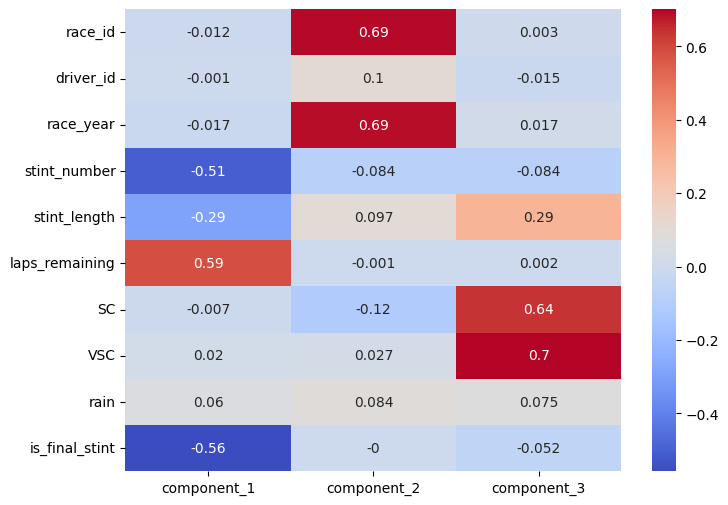

In [54]:
# Visualización PCA loadings por variable y componente.
plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm")
plt.show()